In [372]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [373]:
df = pd.read_csv('/content/adult.data', header=None,  names=["age", "workclass", "fnlwgt", "education", "education-num", "marital-status", "occupation","relationship", "race", "sex","capital-gain","capital-loss","hours-per-week","native-country", 'income'])
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [374]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [375]:
df2 = pd.read_csv('/content/adult.test')
df2.head()

,,,,,,,,,,,,,,|1x3 Cross validator
25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K.
38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K.
28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K.
44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K.
18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K.


In [376]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [377]:
df.shape

(32561, 15)

In [378]:
df.drop_duplicates(inplace=True)

In [379]:
df.shape

(32537, 15)

In [380]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education-num   32537 non-null  int64 
 5   marital-status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital-gain    32537 non-null  int64 
 11  capital-loss    32537 non-null  int64 
 12  hours-per-week  32537 non-null  int64 
 13  native-country  32537 non-null  object
 14  income          32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 4.0+ MB


In [381]:
df['income'] = df['income'].apply(lambda x: 1 if x == ' >50K' else 0)
# df['income_binary'] = df['income'].apply(lambda x: 1 if x == ' >50K' else 0)

In [382]:
# separting Numerical Variales
df_numerical = df.select_dtypes(include=['float64', 'int64'])
df_numerical.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,0
1,50,83311,13,0,0,13,0
2,38,215646,9,0,0,40,0
3,53,234721,7,0,0,40,0
4,28,338409,13,0,0,40,0


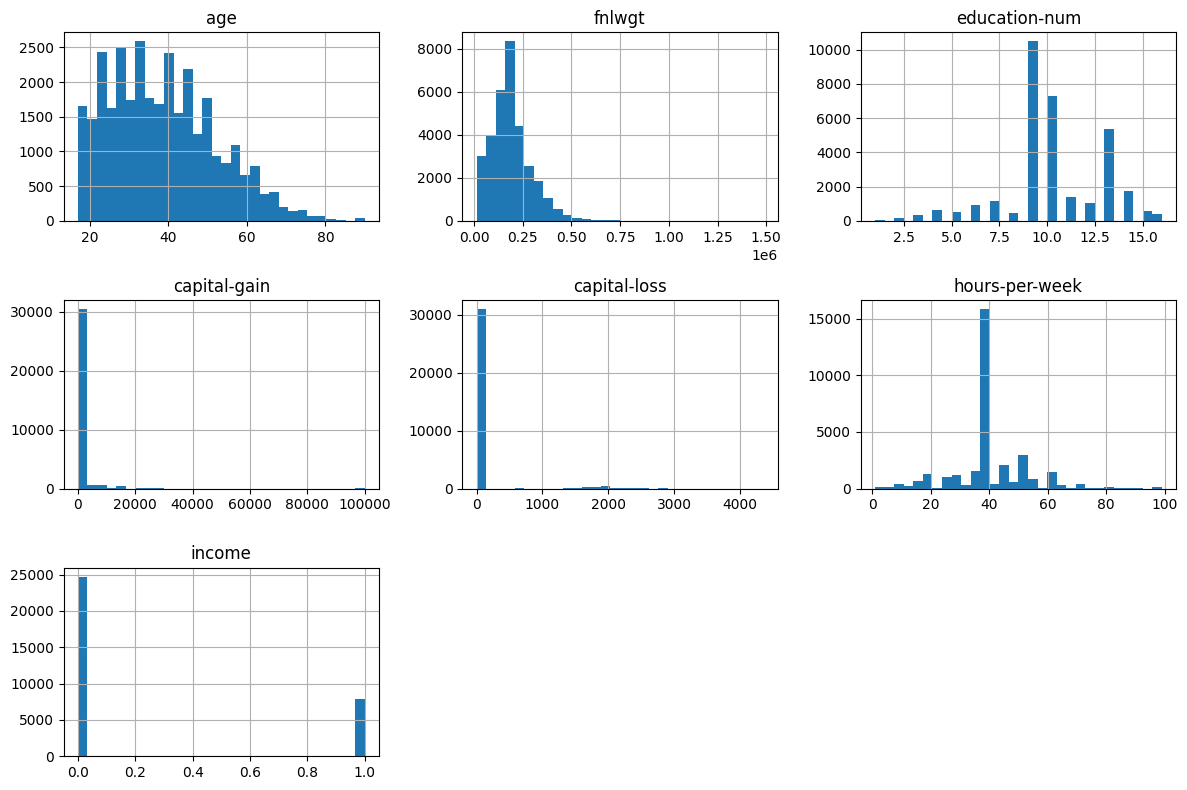

In [383]:
# Histogram for all numeric columns
df.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

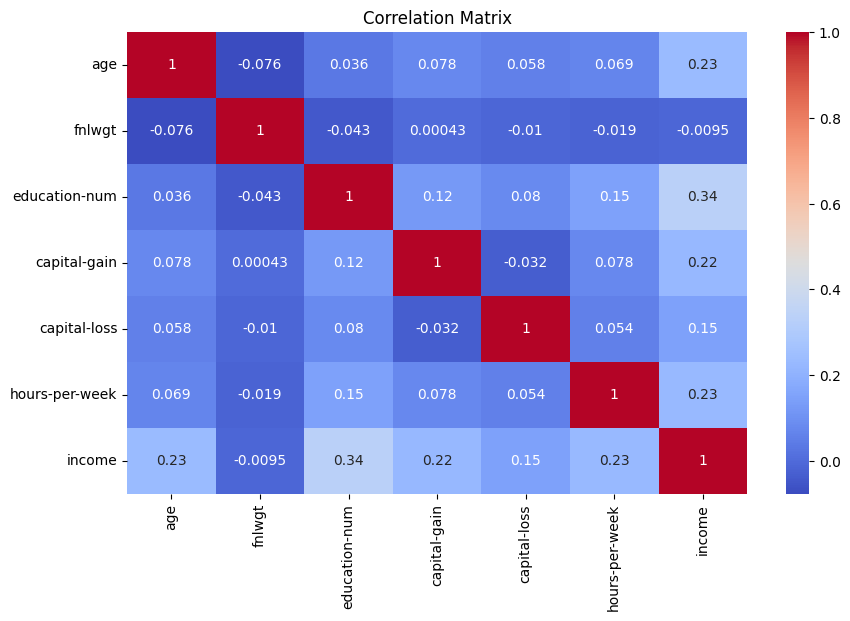

In [384]:
# co-relation

corr = df_numerical.corr()

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [385]:
# df.head(10)
# df['income'].unique()

In [386]:
#  Prune low-impact features
#  droping fnlwgt
df.drop(columns=['fnlwgt'], inplace=True)

In [387]:
# as there is huge skewness in capital gain and loss


df['capital-gain'] = np.log1p(df['capital-gain'])
df['capital-loss'] = np.log1p(df['capital-loss'])

In [388]:
df.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,income
count,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000,32537.000000
mean,38.585549,10.081815,0.735163,0.350563,40.440329,0.240926
std,13.637984,2.571633,2.455562,1.585137,12.346889,0.427652
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,11.512925,8.379539,99.000000,1.000000


In [389]:
# applying models


# Feature selection
numerical_features = ['education-num', 'age', 'hours-per-week', 'capital-gain', 'capital-loss']
X = df[numerical_features]
y = df['income']  # already binary

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}


# Evaluate and store results
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# Display results as a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.808236   0.670175  0.405176  0.505024
1        Decision Tree  0.808851   0.651824  0.447179  0.530448
2        Random Forest  0.818480   0.675465  0.477726  0.559642


In [390]:
# catgorical columns
df_categorical = df.select_dtypes(include='object')
df_categorical.columns

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'native-country'],
      dtype='object')

In [391]:
# now apply OneHotEncoder on cat columns
categorical_cols = df_categorical.columns

# One-hot encode categorical features
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
categorical_data = encoder.fit_transform(df[categorical_cols])
categorical_df = pd.DataFrame(categorical_data, columns=encoder.get_feature_names_out(categorical_cols))
categorical_df.index = df.index

# for the Numerical Data

numerical_df = pd.DataFrame(X_scaled, columns=numerical_features)
numerical_df.index = df.index
#  Combine both sets of features
X = pd.concat([numerical_df, categorical_df], axis=1)
y = df['income']



In [392]:
X.shape

(32537, 99)

In [393]:
#  Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train and evaluate models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

# --- Step 8: Show results as table
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.844806   0.711133  0.601612  0.651804
1        Decision Tree  0.816841   0.619387  0.626220  0.622785
2        Random Forest  0.847367   0.707714  0.626644  0.664716


In [394]:
from sklearn.decomposition import PCA

# Apply PCA on the combined X
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X)  # X from previous step with combined features

# Train/test split on PCA-reduced data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.3, random_state=42)


pca_results = []

for name, model in models.items():
    model.fit(X_train_pca, y_train_pca)
    y_pred = model.predict(X_test_pca)
    pca_results.append({
        'Model': f'{name} PCA',
        'Accuracy': accuracy_score(y_test_pca, y_pred),
        'Precision': precision_score(y_test_pca, y_pred),
        'Recall': recall_score(y_test_pca, y_pred),
        'F1 Score': f1_score(y_test_pca, y_pred)
    })

In [395]:
# --- Step 4: Combine PCA results with previous ones
combined_results_df = pd.concat([results_df, pd.DataFrame(pca_results)], ignore_index=True)
print(combined_results_df)

                     Model  Accuracy  Precision    Recall  F1 Score
0      Logistic Regression  0.844806   0.711133  0.601612  0.651804
1            Decision Tree  0.816841   0.619387  0.626220  0.622785
2            Random Forest  0.847367   0.707714  0.626644  0.664716
3  Logistic Regression PCA  0.834460   0.696760  0.556640  0.618868
4        Decision Tree PCA  0.796353   0.577423  0.583793  0.580591
5        Random Forest PCA  0.839992   0.691382  0.609249  0.647722


### Sig numerical feature is good or PCA-6 is good?

As we can see there is Slighte change in PCA and without PCA, especially in recall and F1, Original features are more interpretable and deliver better accuracy and F1.